# 07 · Gridded Climate & Environmental Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ByMaxAnjos/LCZ4py/blob/main/notebooks/general/07_gridded_climate_environment.en.ipynb)

**Learning objective**: learn to pull external gridded climate and environmental datasets — precipitation (CHIRPS), reanalysis climate (ERA5-Land, regional and global), drought stress (PDSI), and air pollution (GHAP, MERRA-2) — crop them onto an LCZ map's exact pixel grid, and relate them to Local Climate Zone classes to understand how urban form shapes local climate exposure.

## Why bring gridded climate data onto the LCZ grid?

The Local Climate Zone (LCZ) scheme (Stewart & Oke, 2012) classifies urban and natural land into 17 classes based on surface structure, cover, and material properties — compact high-rise, open low-rise, dense trees, water, etc. On its own, an LCZ map tells you about urban *form*. It becomes an urban climate diagnostic once you overlay it with independent, gridded environmental data: precipitation, temperature, humidity, drought stress, and air pollution. Every one of these grids interacts with urban form in well-documented ways:

- **Precipitation** interacts with imperviousness: LCZ 1-3 (compact/high building density) have far less pervious surface than LCZ 6/9 (open low-rise) or LCZ A-D (natural land), so a CHIRPS rainfall event produces very different runoff and flash-flood risk depending on which LCZ it falls on, even if the rain itself is spatially near-uniform at ~5 km resolution.
- **Reanalysis temperature/humidity** (ERA5-Land) sits at a coarser grid (~10 km, or ~9 km native for the global product) than the LCZ classification itself, but is still the standard baseline against which local urban heat island (UHI) signals are measured — the anomaly between station or satellite observations and the ERA5 "background" climate is a common UHI diagnostic (see the local/ notebook series for point-based UHI).
- **Drought indices** (PDSI, from TerraClimate or NOAA PSL) integrate precipitation and potential evapotranspiration over time. Because impervious LCZ classes reduce infiltration and increase runoff, the same drought signal can translate into more acute water stress for urban vegetation and green infrastructure in LCZ classes with low pervious fraction.
- **Air pollution** (GHAP PM2.5/O3/CO, MERRA-2 aerosols) is shaped by urban form through two opposing mechanisms: dense built-up LCZ classes (1-3, 8-10) tend to trap pollutants via reduced ventilation (high sky-view-factor obstruction, "street canyon" effects), while LCZ classes with more vegetation (A-D) both dilute pollutant concentrations and physically scrub particulates from the air.

Anjos et al. (2025, *Scientific Reports*, https://www.nature.com/articles/s41598-025-92000-0) — the paper behind the LCZ4r/LCZ4py toolchain — makes the case that these environmental layers are only interpretable in the context of the surface structure they sit on top of; a raw temperature or PM2.5 raster says little about *why* a hotspot exists until you know whether it overlays LCZ 2 (compact mid-rise) or LCZ D (low plants).

This notebook covers the **`lcz_grid_*` family** of functions, which all follow the same contract: given an LCZ map GeoTIFF (from `lcz_get_map` or a variant), they download a gridded external dataset, crop and reproject it onto the *exact* pixel grid of the LCZ map (same shape, transform, CRS), and return an `LCZGridResult` — a multi-band array with NaN outside the LCZ map's valid footprint. Because every `lcz_grid_*` output is already pixel-aligned to the LCZ map, no separate spatial join is needed to relate them: the next notebook's `lcz_cal_indexes` (introduced conceptually here, covered per-function in the `05_spectral_indices` notebook) and this notebook's `plot_lcz_relationship` both work directly off that shared grid.

In [1]:
# !pip -q install "LCZ4py[all] @ git+https://github.com/ByMaxAnjos/LCZ4py.git"  # skipped for local execution; needed for Colab

## Reference map

We start from a small, fast-to-download LCZ map with `lcz_get_map`. **Juiz de Fora** (Liechtenstein) keeps the bounding box tiny, which matters for every download in this notebook. One function (`lcz_grid_era5`) needs a Latin-American footprint due to its data source's coverage, so we switch cities just for that one cell — noted clearly when we get there.

In [2]:
from LCZ4py import lcz_get_map

map_path = lcz_get_map(city="Juiz de Fora")
print(map_path)

06:43:16 - LCZ4py._internal._lcz_map_engine - INFO - Loading clipped map from local cache.


/Users/co2map/.lcz4r_cache/clipped_a8db9faa23e32c3b.tif


## `lcz_grid_chirps` — CHIRPS precipitation

CHIRPS (Funk et al. 2015) is a quasi-global ~5 km daily/monthly/annual rainfall dataset (1981-present, UCSB Climate Hazards Center), no authentication required. Key parameters:

- `resolution`: `"monthly"` (mm/month, default), `"daily"` (mm/day), or `"annual"` (mm/year).
- `years`, `months`: which periods to download; defaults to the last two complete years / all 12 months.
- `resampling`: how the source pixels are regridded onto the LCZ map's grid — `"average"` (default, best for a coarse-to-fine rainfall field), `"bilinear"`, or `"nearest"`.

It returns an `LCZGridResult` whose `.array` is `(n_periods, H, W)` float32 mm, NaN outside the LCZ map's valid pixels, and `.bands` gives the ISO date for each layer. We request one year of monthly data, small enough to run live.

In [3]:
from LCZ4py import lcz_grid_chirps

chirps = lcz_grid_chirps(map_path, resolution="monthly", years=[2023], isave=True)
print(chirps.array.shape, chirps.bands[:3], "...", chirps.bands[-3:])
print("units:", chirps.units)

06:43:17 - LCZ4py.general.lcz_grid_chirps - INFO - Saved: /Users/co2map/Documents/lcz4r_python/notebooks/general/LCZ4r_output/lcz_grid_chirps.tif


Using cached CHIRPS stack.
Complete: CHIRPS stack with 12 band(s), cropped to the LCZ map.
(12, 120, 131) ['2023-01-01', '2023-02-01', '2023-03-01'] ... ['2023-10-01', '2023-11-01', '2023-12-01']
units: mm


**Reading the output**: `chirps.array.shape` is `(12, H, W)` — one band per month of 2023. Values are in mm/month; over a small alpine city like Juiz de Fora you should see a seasonal cycle (typically wetter summer months). NaN pixels fall outside the LCZ map's footprint. This is the raster we'll use below for `plot_grid_only` and `plot_lcz_relationship`.

## `lcz_grid_era5` — ERA5-Land daily climate (Latin America mirror)

`lcz_grid_era5` downloads ERA5-Land daily aggregates from a Zenodo mirror (Saldanha, 1950-2025, ~10 km) — no authentication required, **but its coverage is genuinely Latin-America-only** (the mirror only holds data for roughly lon -119..-34, lat -57..34). Calling it on a map outside that window raises a clear `ValueError` pointing at `lcz_grid_era5_global` instead of failing deep inside a "no data" extraction error.

Because Juiz de Fora sits in Central Europe, we switch to **Montevideo, Uruguay** for this one function only. Key parameters:

- `years` (required), `months`: period to import.
- `vars`: variable alias(es) or `"all"` — options are `t2m`, `t2m_max`, `t2m_min`, `td2m` (dewpoint), `u10`/`v10` (wind components), `sp` (surface pressure), `tp` (precipitation). Default `("t2m", "tp")`.
- `resampling`: `"average"` (default), `"bilinear"`, or `"nearest"`.

Unit conversions are applied automatically: temperature K→°C, precipitation m→mm, pressure Pa→hPa.

In [4]:
from LCZ4py import lcz_get_map, lcz_grid_era5

# Coverage limitation: lcz_grid_era5's Zenodo mirror is Latin-America-only,
# so we use Montevideo here instead of Juiz de Fora.
map_path_latam = lcz_get_map(city="Montevideo")

era5 = lcz_grid_era5(map_path_latam, years=[2023], months=[1, 2], vars=("t2m", "tp"))
print(era5.array.shape, era5.bands[:3])
print("variables:", era5.variables, "| units:", era5.units)

06:43:17 - LCZ4py._internal._lcz_map_engine - INFO - Loading clipped map from local cache.


Using cached ERA5-Land stack.
Complete: ERA5-Land stack with 118 band(s), cropped to the LCZ map.
(118, 264, 462) ['t2m_2023-01-01', 't2m_2023-01-02', 't2m_2023-01-03']
variables: ['t2m', 'tp'] | units: mixed


**Reading the output**: bands are labelled `"{variable}_{date}"` (e.g. `t2m_2023-01-01`), one band per variable per day. `era5.array.shape` is `(n_vars * n_days, H, W)`. Compare `t2m` values against the CHIRPS rainfall above conceptually: ERA5-Land gives you the atmospheric context (temperature, precipitation) at a coarser ~10 km grid, which the LCZ map's higher-resolution classes locally modulate (urban vs. rural microclimate).

## `lcz_grid_era5_global` — global ERA5-Land via Copernicus CDS

> **Credentials required — free CDS API key**
>
> `lcz_grid_era5_global` covers **any region on Earth** (unlike `lcz_grid_era5`'s Latin-America-only mirror), but pulls data live from the Copernicus Climate Data Store (CDS), which requires a free account and API key:
>
> 1. Register at <https://cds.climate.copernicus.eu> (free).
> 2. Go to your profile page → **API keys** to find your personal key (a UID:key string).
> 3. See the official how-to: <https://cds.climate.copernicus.eu/api-how-to>.
> 4. Pass the key via `cds_key=` (shown below), or set the `CDSAPI_KEY`/`CDSAPI_URL` environment variables, or write a `~/.cdsapirc` file — any of the three works.
>
> **We do NOT execute the cell below** in this notebook (no key is configured in this environment), but the code is real and ready to run once you supply your own key. The CDS request is automatically subset to the LCZ map's bounding box (plus a small margin), so even a real run never transfers global data.

Key parameters (monthly grain only — for daily data over Latin America, use `lcz_grid_era5` instead):

- `years` (required), `months`.
- `vars`: `t2m`, `td2m`, `u10`, `v10`, `sp`, `tp`, `skt` (skin temperature), or `"all"`. (No `t2m_max`/`t2m_min` — the CDS monthly-means product only offers the monthly average.)
- `cds_key`, `cds_url`: credentials (or leave `None` to read from env vars / `~/.cdsapirc`).

In [ ]:
# NOT EXECUTED in this notebook: requires a real CDS API key.
# Replace "<your-CDS-key>" with the UID:key string from your CDS profile page,
# or omit cds_key/cds_url entirely if you have a ~/.cdsapirc file configured.
from LCZ4py import lcz_grid_era5_global

era5_global = lcz_grid_era5_global(
    map_path,
    years=[2023],
    months=[1, 2],
    vars=("t2m", "tp"),
    cds_key="<your-CDS-key>",
    cds_url="https://cds.climate.copernicus.eu/api",
)
print(era5_global.array.shape, era5_global.bands[:3])

*(Skipped: no CDS key available in this environment. With a valid key, this returns the same `LCZGridResult` structure as `lcz_grid_era5`, but usable on Juiz de Fora — or any city worldwide — instead of being restricted to Latin America.)*

## `lcz_grid_pdsi` — Palmer Drought Severity Index

PDSI integrates precipitation and potential evapotranspiration into a single drought-stress index: values ≥ +4 indicate extremely wet conditions, -2 to +2 near-normal, and ≤ -4 extreme drought. `lcz_grid_pdsi` downloads a precomputed PDSI product and crops it onto the LCZ grid. Key parameters:

- `source`: `"terraclimate"` (default, ~4 km, 1950-2025, Abatzoglou et al. 2018) or `"noaa_psl"` (2.5°, 1850-2018, Dai 2011 — coarser but a much longer record).
- `years`, `months`: defaults to the last two complete years / all 12 months.
- `resampling`: `"average"` (default), `"bilinear"`, `"nearest"`.

No authentication needed for either source.

In [6]:
from LCZ4py import lcz_grid_pdsi

pdsi = lcz_grid_pdsi(map_path, years=[2023], source="terraclimate", isave=True)
print(pdsi.array.shape, pdsi.bands[:3])
print("variables:", pdsi.variables, "| units:", pdsi.units)

06:43:17 - LCZ4py._internal._lcz_grid_base - INFO - Cache hit: TerraClimate_PDSI_2023.nc


06:43:18 - LCZ4py.general.lcz_grid_pdsi - INFO - Saved: /Users/co2map/Documents/lcz4r_python/notebooks/general/LCZ4r_output/lcz_grid_pdsi.tif


Complete: PDSI stack with 12 band(s), cropped to the LCZ map.
(12, 120, 131) ['2023-01-01', '2023-02-01', '2023-03-01']
variables: ['pdsi'] | units: index


**Reading the output**: each band is a monthly PDSI snapshot. Values close to 0 mean near-normal moisture conditions; persistently negative values across months would flag drought stress that, combined with the CHIRPS rainfall series above, helps disentangle whether a dry period is driven by a short-term rainfall deficit or a longer accumulated water-balance deficit.

## `lcz_grid_pollution_ghap` — GHAP air pollution

GHAP (Global High Air Pollutants, Wei et al.) provides AI-generated ground-level pollutant fields: PM2.5 (1 km, daily/monthly/annual, 2017-2022), O3 (10 km, annual, 2000-2020), CO (1 km, annual, 2019-2022), hosted on Zenodo — no authentication required. Key parameters:

- `pollutants`: `"pm25"` (default), `"o3"`, `"co"`, or `"all"`. O3/CO silently fall back to `"annual"` resolution regardless of what you request.
- `resolution`: `"daily"`/`"monthly"` (PM2.5 only) or `"annual"` (all pollutants).
- `years`, `months`: defaults to all available years per pollutant/resolution.

In [7]:
from LCZ4py import lcz_grid_pollution_ghap

ghap = lcz_grid_pollution_ghap(map_path, pollutants="pm25", resolution="monthly", years=[2020], months=[6, 7, 8])
print(ghap.array.shape, ghap.bands)
print("units:", ghap.units)

06:43:18 - LCZ4py._internal._lcz_grid_base - INFO - Cache hit: GHAP_PM2.5_M1K_202006_V1.nc


06:43:18 - LCZ4py._internal._lcz_grid_base - INFO - Cache hit: GHAP_PM2.5_M1K_202007_V1.nc


06:43:18 - LCZ4py._internal._lcz_grid_base - INFO - Cache hit: GHAP_PM2.5_M1K_202008_V1.nc


Complete: GHAP stack with 3 band(s), cropped to the LCZ map.
(3, 120, 131) ['pm25_2020-06-01', 'pm25_2020-07-01', 'pm25_2020-08-01']
units: ug_m3


**Reading the output**: bands are `"pm25_{date}"`, one per requested month. Higher PM2.5 (µg/m³) values concentrated over compact/dense LCZ classes (1-3, 8-10) vs. lower values over vegetated classes (A-D) would be consistent with the urban-canyon trapping vs. vegetation-scrubbing mechanisms described in the intro.

## `lcz_grid_pollution_merra2` — MERRA-2 aerosols

> **Credentials required — free NASA Earthdata Login**
>
> `lcz_grid_pollution_merra2` downloads NASA's MERRA-2 aerosol reanalysis (Gelaro et al. 2017) from the GES DISC archive, which requires a free NASA Earthdata account:
>
> 1. Register at <https://urs.earthdata.nasa.gov/users/new> (free).
> 2. Use your Earthdata **username/password** directly, or generate a `.netrc` file (see NASA's Earthdata Login documentation for the exact format) and point `netrc_path` at it.
> 3. Pass credentials via `earthdata_user=`/`earthdata_pass=` (shown below), or set the `EARTHDATA_USER`/`EARTHDATA_PASSWORD` environment variables.
>
> **We do NOT execute the cell below** (no Earthdata login is configured in this environment), but the code is real and ready to run with your own credentials.

Key parameters:

- `pollutants`: subset of `("pm25", "aod", "so2")`. PM2.5 is derived from five aerosol mass-concentration species; AOD is total aerosol optical depth; SO2 is monthly-only.
- `resolution`: `"monthly"` (default) or `"daily"` — note that MERRA-2's daily path isn't implemented upstream in GES DISC's public archive, so both resolutions currently return the same monthly-mean file (documented limitation, ported as-is from the R package for parity).
- `earthdata_user`, `earthdata_pass`, `netrc_path`: authentication.

In [ ]:
# NOT EXECUTED in this notebook: requires real NASA Earthdata credentials.
from LCZ4py import lcz_grid_pollution_merra2

merra2 = lcz_grid_pollution_merra2(
    map_path,
    pollutants=("pm25", "aod"),
    resolution="monthly",
    years=[2022],
    months=[6, 7, 8],
    earthdata_user="<your-earthdata-username>",
    earthdata_pass="<your-earthdata-password>",
)
print(merra2.array.shape, merra2.bands)

*(Skipped: no Earthdata login configured in this environment. With valid credentials, this returns the same `LCZGridResult` structure as `lcz_grid_pollution_ghap`, giving a second, independent aerosol/pollution source you can cross-check against GHAP for the same city/period.)*

## `plot_grid_only` — static grid/mesh visualization

`plot_grid_only` renders any vector grid/mesh `GeoDataFrame` (polygons or points) over an OpenStreetMap basemap using Matplotlib + contextily — handy for a quick static look at municipality boundaries, LCZ zone polygons, or (as here) the pixel grid of a `lcz_grid_*` raster output. Key parameters:

- `color_by`: column name to color features by (`None` for a single uncolored fill).
- `cmap`: Matplotlib colormap for `color_by`. Default `"viridis"`.
- `add_basemap`: overlay an OSM basemap via contextily (skipped gracefully if contextily isn't installed).

Since `plot_grid_only` expects a `GeoDataFrame` rather than a raw raster array, we vectorize one band of the CHIRPS output we saved above (`isave=True` wrote it to `LCZ4r_output/lcz_grid_chirps.tif`) into polygons with `rasterio.features.shapes`, then plot it.

06:43:18 - rasterio._env - WARNING - CPLE_AppDefined in DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


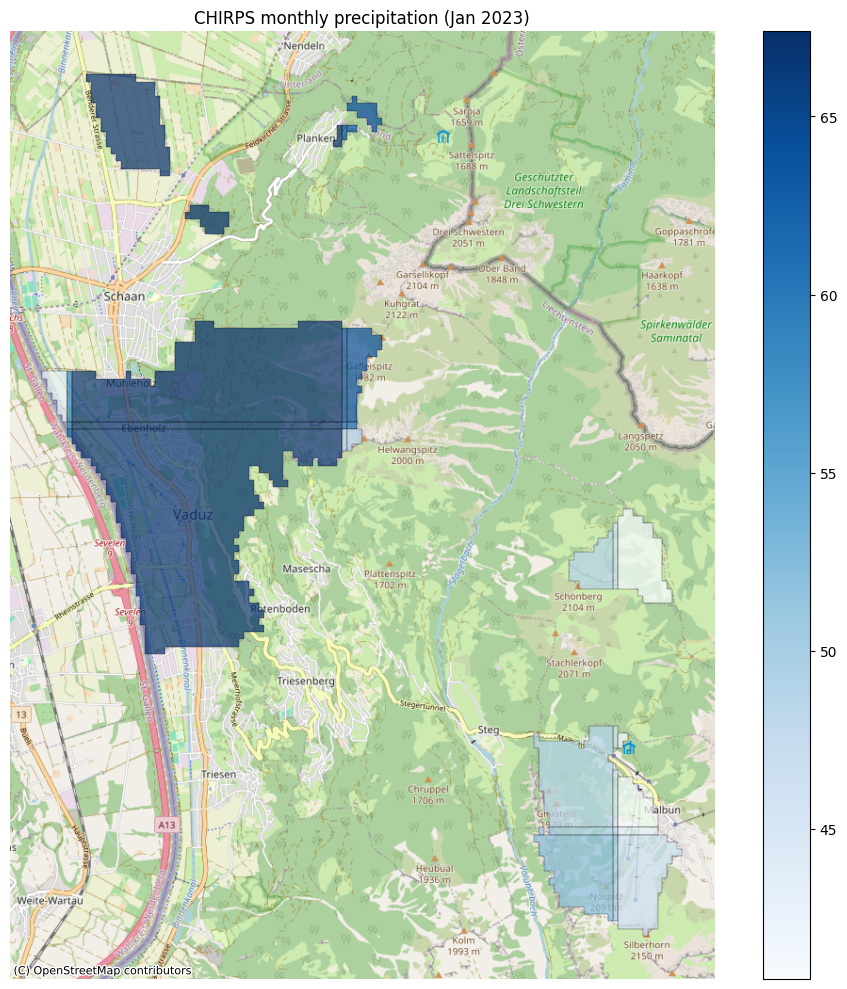

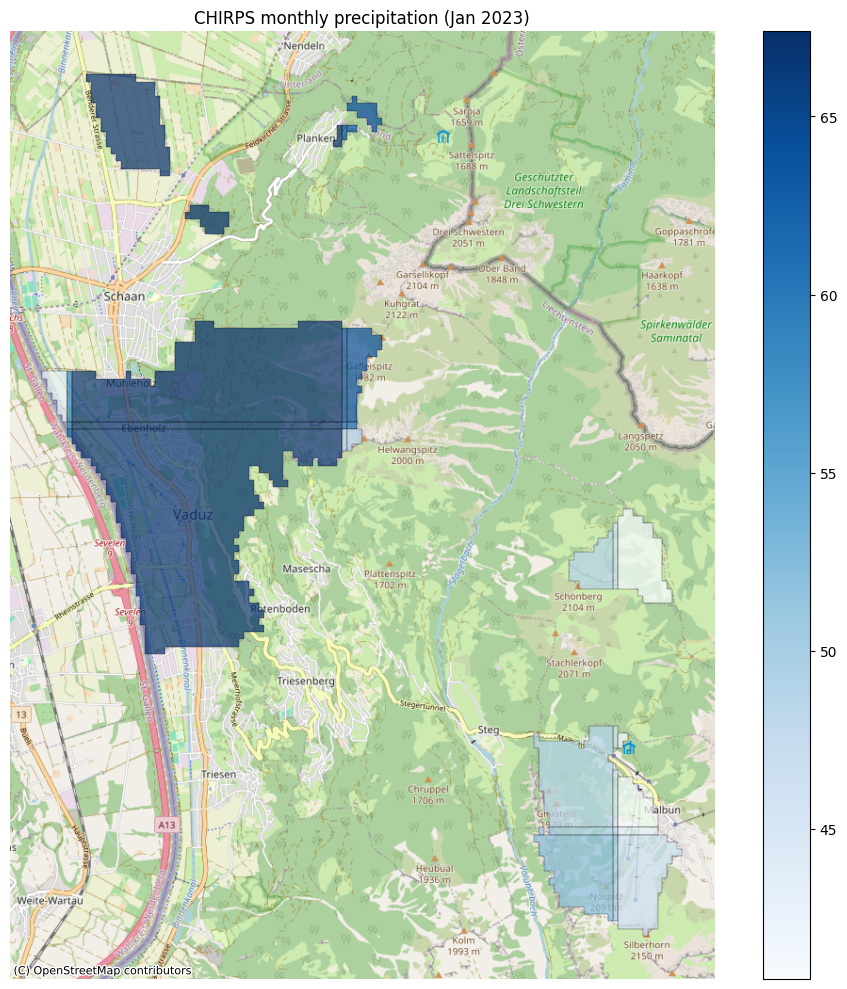

In [9]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape

from LCZ4py import plot_grid_only

with rasterio.open("LCZ4r_output/lcz_grid_chirps.tif") as src:
    band = src.read(1)
    transform = src.transform
    crs = src.crs

valid_mask = ~np.isnan(band)
polygons, values = [], []
for geom, val in shapes(band, mask=valid_mask, transform=transform):
    polygons.append(shape(geom))
    values.append(val)

grid_gdf = gpd.GeoDataFrame({"precip_mm": values}, geometry=polygons, crs=crs)
fig = plot_grid_only(grid_gdf, color_by="precip_mm", cmap="Blues", title="CHIRPS monthly precipitation (Jan 2023)")
fig

**Reading the output**: each polygon is one CHIRPS pixel reprojected onto the LCZ grid, colored by January-2023 rainfall (mm). Because the underlying raster was masked to the LCZ map's valid footprint, only pixels inside the city boundary are shown — you're looking at the actual spatial pattern of rainfall the LCZ classes below are exposed to.

## `plot_lcz_relationship` — variable distribution by LCZ class

`plot_lcz_relationship` is the quick visual counterpart to `lcz_cal_indexes` (covered in the `05_spectral_indices` notebook, and the general tool for summarizing *any* gridded variable by LCZ class as a table). It reads an LCZ classification GeoTIFF and a single-band environmental raster (reprojecting the latter onto the former's grid if needed), then plots the variable's distribution grouped by LCZ class. Key parameters:

- `variable_name`: axis label for the value.
- `plot_type`: `"box"`/`"violin"` (distribution per class), `"scatter"` (per-pixel jittered), or `"heatmap"` (one aggregated value per class).
- `agg_fun`: aggregation for `"heatmap"` — `"mean"` (default), `"median"`, `"sum"`.

We use it here on the CHIRPS precipitation stack (using a single band as a representative single-band raster) to see how rainfall exposure differs by LCZ class within Juiz de Fora.

In [10]:
import rasterio

from LCZ4py import plot_lcz_relationship

# Extract a single band (January 2023) to a standalone single-band GeoTIFF,
# since plot_lcz_relationship expects a single-band variable raster.
with rasterio.open("LCZ4r_output/lcz_grid_chirps.tif") as src:
    band1 = src.read(1)
    profile = src.profile.copy()
profile.update(count=1)
variable_path = "LCZ4r_output/lcz_grid_chirps_jan2023.tif"
with rasterio.open(variable_path, "w", **profile) as dst:
    dst.write(band1, 1)

fig = plot_lcz_relationship(map_path, variable_path, variable_name="precip_mm (Jan 2023)", plot_type="box")
fig

06:43:31 - rasterio._env - WARNING - CPLE_IllegalArg in lcz_grid_chirps_jan2023.tif: BLOCKXSIZE can only be used with TILED=YES


**Reading the output**: the box plot shows the January-2023 CHIRPS rainfall distribution for every LCZ class present in Juiz de Fora. Since precipitation itself doesn't vary much with urban form at CHIRPS's ~5 km resolution over such a small city, expect the boxes to look broadly similar across classes here — the more striking version of this plot appears with a variable that genuinely responds to urban structure, like the GHAP PM2.5 stack above (try swapping in `LCZ4r_output/lcz_grid_ghap.tif`, extracting one band the same way, to see class-dependent pollution patterns instead). This is exactly the kind of exploration `lcz_cal_indexes` (see `05_spectral_indices`) turns into a reusable, per-class statistics table when you need numbers rather than a chart.

## Conclusion & next steps

This notebook covered the full `lcz_grid_*` family for bringing external gridded environmental context onto an LCZ map's pixel grid:

- **`lcz_grid_chirps`** — precipitation, no auth, global.
- **`lcz_grid_era5`** — daily reanalysis climate, no auth, Latin-America-only coverage.
- **`lcz_grid_era5_global`** — monthly reanalysis climate, any region, requires a free CDS API key.
- **`lcz_grid_pdsi`** — drought severity index, no auth, global.
- **`lcz_grid_pollution_ghap`** — PM2.5/O3/CO, no auth, global.
- **`lcz_grid_pollution_merra2`** — aerosol reanalysis, requires a free NASA Earthdata login.

Plus two visualization helpers: **`plot_grid_only`** for a quick static look at any vector grid/mesh, and **`plot_lcz_relationship`** for a fast visual read of how a gridded variable distributes across LCZ classes — the visual counterpart to the tabular `lcz_cal_indexes` (see `05_spectral_indices`).

This is the **last notebook in the `general/` series**. Together with `01_map_acquisition` through `06_urban_canopy_parameters`, you now have the full toolkit for acquiring, describing, and contextualizing an LCZ map for any city on Earth. The series continues in **`notebooks/local/01_lcz_time_series`**, which shifts from whole-map raster analysis to station-based, point-level air-temperature time series — the starting point for the local/ series covering temperature anomalies, urban heat island intensity, spatial interpolation, and thermal comfort.